## NoteBook by
### - Himel Sarder

In [2]:
import numpy as np
import pandas as pd

In [144]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [145]:
df = pd.read_csv('car_resale_data.csv')

In [146]:
df.head()

,Age (Years),Mileage (Km),Engine_Size (L),Resale_Price
0,7,71617,1.3,21369.15
1,4,21896,3.4,30005.20
2,13,135798,1.2,12010.10
3,11,182247,3.5,15137.65
4,8,143877,1.2,16606.15


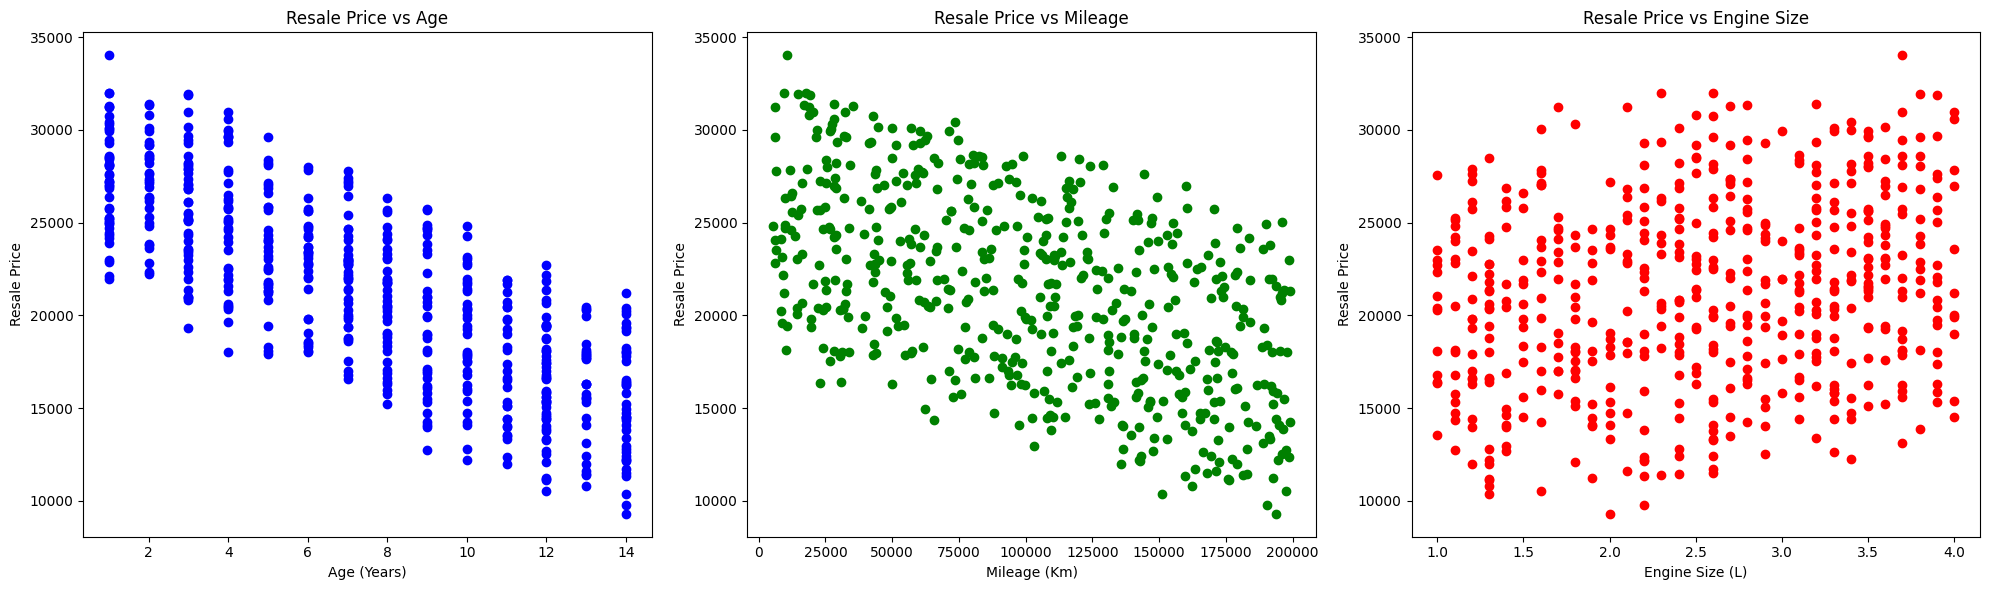

In [147]:
# Plotting Resale_Price vs Age
plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 1)
plt.scatter(df['Age (Years)'], df['Resale_Price'], color='blue')
plt.title('Resale Price vs Age')
plt.xlabel('Age (Years)')
plt.ylabel('Resale Price')

# Plotting Resale_Price vs Mileage
plt.subplot(1, 3, 2)
plt.scatter(df['Mileage (Km)'], df['Resale_Price'], color='green')
plt.title('Resale Price vs Mileage')
plt.xlabel('Mileage (Km)')
plt.ylabel('Resale Price')

# Plotting Resale_Price vs Engine_Size
plt.subplot(1, 3, 3)
plt.scatter(df['Engine_Size (L)'], df['Resale_Price'], color='red')
plt.title('Resale Price vs Engine Size')
plt.xlabel('Engine Size (L)')
plt.ylabel('Resale Price')

# Display the plots
plt.tight_layout()
plt.show()

In [148]:
X = df.drop(columns=['Resale_Price'])
y = df['Resale_Price']

In [149]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [150]:
X_train.head()

,Age (Years),Mileage (Km),Engine_Size (L)
482,1,152820,2.0
158,3,107795,2.4
15,4,145734,3.5
334,14,103142,3.3
39,10,31646,1.3


In [151]:
# Without binarization

model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)  # Mean Squared Error
r2 = r2_score(y_test, y_pred)  # R-squared

In [152]:
# Output results
print("Linear Regression Model Results:")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Coefficients and intercept
print("\nModel Coefficients:")
print(f"Intercept: {model.intercept_}")
print(f"Coefficients: {model.coef_}")

Linear Regression Model Results:
Mean Squared Error: 1.755036625477509e-21
R-squared: 1.0

Model Coefficients:
Intercept: 29999.99999999991
Coefficients: [-1.0e+03 -5.0e-02  1.5e+03]


In [153]:
score = np.mean(cross_val_score(LinearRegression(), X, y, cv=10, scoring='r2'))
print(f"Cross-validation R-squared score: {score}")

Cross-validation R-squared score: 1.0


In [154]:
# Applying Binarization

from sklearn.preprocessing import Binarizer

In [155]:
trf = ColumnTransformer([
    ('age_bin', Binarizer(threshold=5.0, copy=False), [0]),  # Age > 5 gets 1, otherwise 0
    ('engine_bin', Binarizer(threshold=2.0, copy=False), [2]),  # Engine Size > 2.0 gets 1, otherwise 0
    ('mileage_scale', StandardScaler(), [1])  # Standardizing Mileage
], remainder='passthrough')

In [156]:
trf

ColumnTransformer(remainder='passthrough',
                  transformers=[('age_bin',
                                 Binarizer(copy=False, threshold=5.0), [0]),
                                ('engine_bin',
                                 Binarizer(copy=False, threshold=2.0), [2]),
                                ('mileage_scale', StandardScaler(), [1])])

In [157]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [158]:
df1 = pd.DataFrame(X_train_trf, columns=['Age_Bin', 'Engine_Size_bin', 'Mileage (Km)_scale'])

df1.head(10)

,Age_Bin,Engine_Size_bin,Mileage (Km)_scale
0,0.0,0.0,0.917222
1,0.0,1.0,0.124013
2,0.0,1.0,0.792387
3,1.0,1.0,0.042041
4,1.0,0.0,-1.217509
5,0.0,1.0,-1.398647
6,0.0,1.0,1.230471
7,1.0,0.0,1.329637
8,0.0,1.0,-0.359434
9,1.0,1.0,-1.181341


In [159]:
clf = LinearRegression()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

mse = mean_squared_error(y_test, y_pred2)  # Mean Squared Error
r2 = r2_score(y_test, y_pred2)  # R-squared
print("Linear Regression Model Results:")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Linear Regression Model Results:
Mean Squared Error: 5610608.866894091
R-squared: 0.771308108508918


In [160]:
from sklearn.model_selection import cross_val_score
score = np.mean(cross_val_score(LinearRegression(), X, y, cv=10, scoring='r2'))
print(f"Cross-validation R² score: {score}")

Cross-validation R² score: 1.0
